# Exercise: Statistics – sample vs population metrics

As data scientists working for an environmental organisation, our task is to analyse data related to forest areas across different regions to help formulate conservation strategies. The dataset includes forest areas (in square kilometres) from over 1,000 regions worldwide.

### Exercise 1

We are working with a dataset that contains information about different species found in national parks around the world. The dataset includes data on the number of individual animals of each species found in these parks.

Task: Generate a reproducible data. Then calculate the population mean (`population_mean`) and variance (`population_variance`) of the species count. 

In [7]:
# import essential libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Generating the data
np.random.seed(0) # This is for reproducibility

species_count = np.random.randint(500, 10000, 1000) # Generating random numbers for each species
region = ['Region ' + str(i) for i in species_count]

data = {'Region': region, 'Number_of_Species': species_count}
df = pd.DataFrame(data)

# Population mean
population_mean = df['Number_of_Species'].mean()

# Population variance
population_variance = df['Number_of_Species'].var(ddof=0)

# Print results
print(f"The Population mean is: {population_mean}")
print(f"The Population variance is: {population_variance}")

The Population mean is: 5378.98
The Population variance is: 7517438.4416


### Exercise 2

Select a random sample of 30 regions from the dataset and calculate sample mean and variance. Compare these with population metrics.

In [14]:
# Calculating sample mean and variance using a sample size of 30
# sample size
sample = df.sample(30)

# sample mean
sample_mean = sample['Number_of_Species'].mean()

# sample variance
sample_variance = sample['Number_of_Species'].var(ddof=1)

# Comparison
mean_difference = population_mean - sample_mean
variance_difference = population_variance - sample_variance

# print results
print(f"The Sample mean is: {sample_mean:.4f}")
print(f"The Sample variance is: {sample_variance:.4f}")

print(f"\nComparing the mean and varaince difference of the sample and population")
print(f"The Mean difference: {mean_difference:.4f}")
print(f"The Variance difference: {variance_difference:.4f}")



The Sample mean is: 5807.4333
The Sample variance is: 5368974.2540

Comparing the mean and varaince difference of the sample and population
The Mean difference: -428.4533
The Variance difference: 2148464.1876


### Exercise 3

Demonstrate the central limit theorem (CLT) by plotting the distribution of sample means.

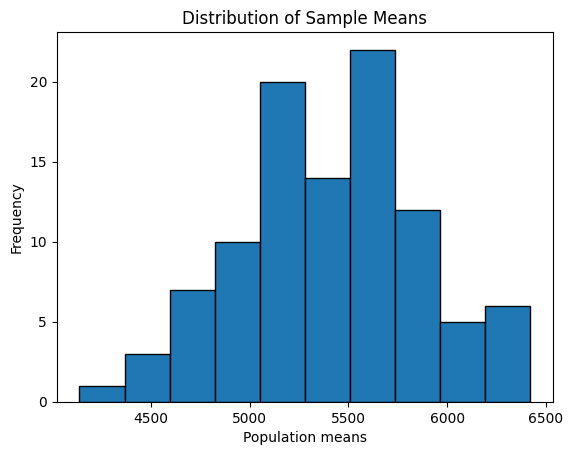

In [23]:
# generating sample means
sample_means = [np.mean(df['Number_of_Species'].sample(30)) for _ in range(100)]

# Generating the plot
plt.hist(sample_means, bins=10, edgecolor='black')
plt.xlabel('Population means')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Means')
plt.show()

### Exercise 4

Calculate a 95% confidence interval for the mean of a sample.

In [26]:
# Calculating the confidence interval
# calculating the sample mean
sample_data = sample['Number_of_Species']
sample_data_mean = np.mean(sample_data)

# Calculating the Standard Error Mean of the sample data
sample_SEM = stats.sem(sample_data)

# calculating the degree of freedom
degree_of_freedom = len(sample_data - 1)

confidence_level = 0.95

confidence_interval = stats.t.interval(confidence_level, degree_of_freedom, sample_data_mean, sample_SEM)

# print result
print(f"The 95% Confidence interval is: {confidence_interval}")


The 95% Confidence interval is: (np.float64(4943.463232008766), np.float64(6671.403434657901))
